# Project 3: Sales Forecasting
## Notebook 5: Hybrid Model — SARIMA + XGBoost on Residuals

**Why a hybrid model?**

SARIMA captures the predictable part of the series (trend + seasonality) perfectly.
But the residuals — what SARIMA *couldn't* explain — still contain patterns.
XGBoost learns those non-linear residual patterns.

Combined result is almost always better than either model alone.

```
Hybrid forecast = SARIMA forecast + XGBoost(residuals) forecast
```

This is a technique used in production forecasting systems at companies like Amazon and Walmart.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import joblib

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (13, 5)

BASE      = Path(r'C:\Users\Administrator\SalesForecast')
PROC_DIR  = BASE / 'data' / 'processed'
MODEL_DIR = BASE / 'models'
FIG_DIR   = BASE / 'reports' / 'figures'

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Split

In [2]:
monthly = pd.read_csv(PROC_DIR / 'monthly_sales.csv', index_col=0, parse_dates=True).squeeze()

TEST_MONTHS = 12
train = monthly[:-TEST_MONTHS]
test  = monthly[-TEST_MONTHS:]

print(f'Train: {len(train)} months | Test: {len(test)} months')
print(f'Date range: {train.index[0].date()} → {test.index[-1].date()}')

Train: 36 months | Test: 12 months
Date range: 2014-01-01 → 2017-12-01


## 2. Step 1 — Fit SARIMA on Training Data

Load the best parameters found in Notebook 2, or fit fresh here.

In [3]:
# Load saved SARIMA params from Notebook 02
try:
    sarima_params = joblib.load(MODEL_DIR / 'sarima_params.pkl')
    best_order    = sarima_params['order']
    best_seasonal = sarima_params['seasonal_order']
    print(f'Loaded SARIMA params: order={best_order}, seasonal={best_seasonal}')
except:
    # Sensible defaults for monthly retail data
    best_order    = (1, 1, 1)
    best_seasonal = (1, 1, 1, 12)
    print(f'Using default SARIMA params: {best_order} × {best_seasonal}')

sarima = SARIMAX(
    train,
    order          = best_order,
    seasonal_order = best_seasonal,
    enforce_stationarity  = False,
    enforce_invertibility = False,
).fit(disp=False)

print('SARIMA fitted on training data.')

Loaded SARIMA params: order=(0, 1, 1), seasonal=(0, 1, 0, 12)
SARIMA fitted on training data.


c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 3. Extract Residuals from SARIMA

Residuals = actual sales − SARIMA's in-sample predictions.
These are the patterns SARIMA couldn't capture.

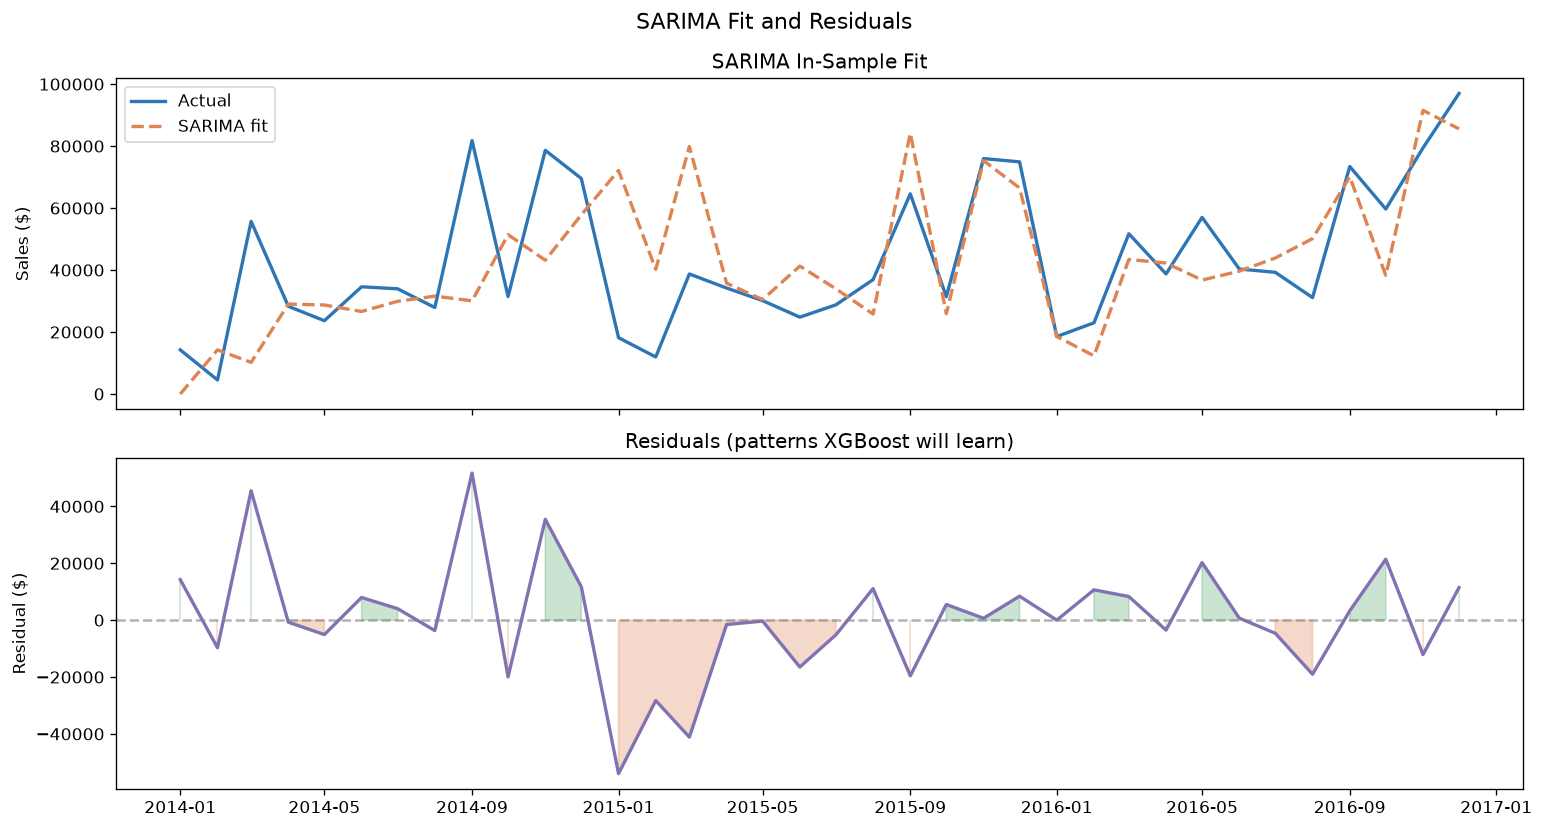

Residuals — mean: $760 | std: $20,689
If mean is near 0, SARIMA captured the main signal well.


In [4]:
sarima_insample = sarima.fittedvalues
residuals       = train - sarima_insample

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(train.index, train.values, label='Actual', color='#2E75B6', lw=2)
axes[0].plot(sarima_insample.index, sarima_insample.values, label='SARIMA fit',
             color='#DD8452', lw=2, linestyle='--')
axes[0].set(title='SARIMA In-Sample Fit', ylabel='Sales ($)')
axes[0].legend()

axes[1].plot(residuals.index, residuals.values, color='#8172B3', lw=2)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.6)
axes[1].fill_between(residuals.index, residuals.values, 0,
                     where=residuals.values > 0, alpha=0.3, color='#55A868')
axes[1].fill_between(residuals.index, residuals.values, 0,
                     where=residuals.values < 0, alpha=0.3, color='#DD8452')
axes[1].set(title='Residuals (patterns XGBoost will learn)', ylabel='Residual ($)')

plt.suptitle('SARIMA Fit and Residuals', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '13_sarima_residuals.png', bbox_inches='tight')
plt.show()

print(f'Residuals — mean: ${residuals.mean():,.0f} | std: ${residuals.std():,.0f}')
print(f'If mean is near 0, SARIMA captured the main signal well.')

## 4. Step 2 — Fit XGBoost on Residuals

We treat residuals as a new time series and build lag features from them.

In [5]:
def build_residual_features(resid_series, lags=[1, 2, 3, 6, 12]):
    """
    Build lag features from the residual series.
    Also adds calendar features — some residual patterns are calendar-driven.
    """
    df = pd.DataFrame({'resid': resid_series})
    df.index = pd.to_datetime(df.index)

    df['month']     = df.index.month
    df['quarter']   = df.index.quarter
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    for lag in lags:
        df[f'resid_lag_{lag}'] = df['resid'].shift(lag)

    df['resid_roll3']  = df['resid'].shift(1).rolling(3).mean()
    df['resid_roll6']  = df['resid'].shift(1).rolling(6).mean()

    return df.dropna()

resid_features = build_residual_features(residuals)
FEAT_COLS = [c for c in resid_features.columns if c != 'resid']

X_resid = resid_features[FEAT_COLS]
y_resid = resid_features['resid']

print(f'Residual feature matrix: {X_resid.shape}')
print(f'Features: {FEAT_COLS}')

Residual feature matrix: (24, 11)
Features: ['month', 'quarter', 'month_sin', 'month_cos', 'resid_lag_1', 'resid_lag_2', 'resid_lag_3', 'resid_lag_6', 'resid_lag_12', 'resid_roll3', 'resid_roll6']


In [6]:
xgb_resid = XGBRegressor(
    n_estimators      = 300,
    max_depth         = 3,       # shallow — residuals are hard to overfit
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    verbosity         = 0,
)
xgb_resid.fit(X_resid, y_resid)
print('XGBoost fitted on residuals.')

# In-sample check: how well does it fit the residuals?
xgb_insample = xgb_resid.predict(X_resid)
resid_mae = mean_absolute_error(y_resid, xgb_insample)
print(f'XGBoost residual fit MAE: ${resid_mae:,.0f}')

XGBoost fitted on residuals.
XGBoost residual fit MAE: $61


## 5. Step 3 — Combine: Hybrid Forecast on Test Period

In [7]:
# SARIMA forecast on test period
sarima_fc   = sarima.get_forecast(steps=TEST_MONTHS)
sarima_pred = sarima_fc.predicted_mean
sarima_ci   = sarima_fc.conf_int(alpha=0.05)

# XGBoost residual correction
# We need residual features for the test period
# Use the actual test residuals' calendar features with zeros for lag (unknown future)
test_resid_feat = pd.DataFrame(index=test.index)
test_resid_feat['month']     = test.index.month
test_resid_feat['quarter']   = test.index.quarter
test_resid_feat['month_sin'] = np.sin(2 * np.pi * test.index.month / 12)
test_resid_feat['month_cos'] = np.cos(2 * np.pi * test.index.month / 12)

# Use last known residuals for lags
last_resids = list(residuals.values[-12:])
for i, lag in enumerate([1, 2, 3, 6, 12]):
    test_resid_feat[f'resid_lag_{lag}'] = last_resids[-lag] if lag <= len(last_resids) else 0

test_resid_feat['resid_roll3'] = np.mean(last_resids[-3:]) if len(last_resids) >= 3 else 0
test_resid_feat['resid_roll6'] = np.mean(last_resids[-6:]) if len(last_resids) >= 6 else 0

# Align columns
for col in FEAT_COLS:
    if col not in test_resid_feat.columns:
        test_resid_feat[col] = 0
test_resid_feat = test_resid_feat[FEAT_COLS]

xgb_correction = xgb_resid.predict(test_resid_feat)

# Hybrid = SARIMA + XGBoost correction
hybrid_pred = sarima_pred.values + xgb_correction

print('Hybrid predictions computed.')

Hybrid predictions computed.


## 6. Evaluate All Models Side-by-Side

In [8]:
def mape(y_true, y_pred):
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

# SARIMA alone
sarima_mape = mape(test.values, sarima_pred.values)
sarima_rmse = np.sqrt(mean_squared_error(test.values, sarima_pred.values))

# Hybrid
hybrid_mape = mape(test.values, hybrid_pred)
hybrid_rmse = np.sqrt(mean_squared_error(test.values, hybrid_pred))

print('=== Model Comparison ===')
print(f'  SARIMA alone  — MAPE: {sarima_mape:.2f}%  RMSE: ${sarima_rmse:,.0f}')
print(f'  Hybrid        — MAPE: {hybrid_mape:.2f}%  RMSE: ${hybrid_rmse:,.0f}')
improvement = sarima_mape - hybrid_mape
print(f'  Improvement:  {improvement:+.2f}% MAPE  ({"better" if improvement > 0 else "no improvement"})')

=== Model Comparison ===
  SARIMA alone  — MAPE: 28.92%  RMSE: $16,677
  Hybrid        — MAPE: 30.11%  RMSE: $17,133
  Improvement:  -1.19% MAPE  (no improvement)


## 7. Visualise — Actual vs SARIMA vs Hybrid

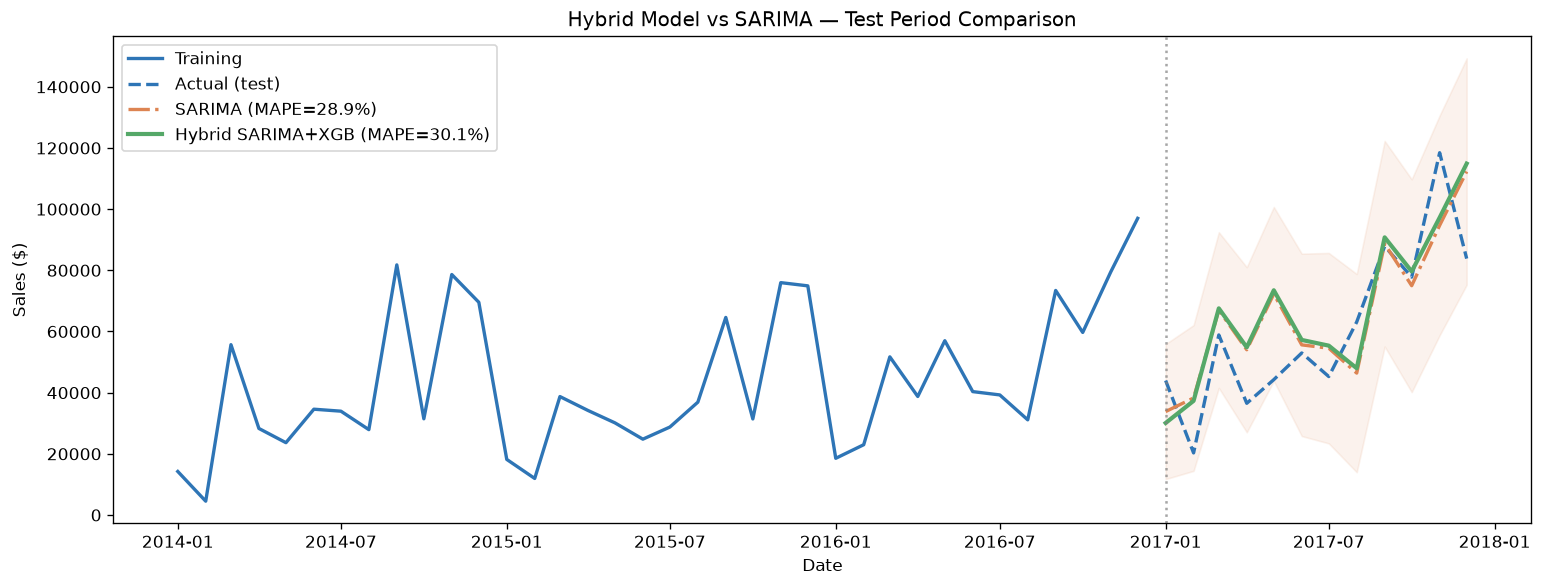

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train.index, train.values, color='#2E75B6', lw=2, label='Training')
ax.plot(test.index,  test.values,  color='#2E75B6', lw=2, linestyle='--', label='Actual (test)')

ax.plot(test.index, sarima_pred.values, color='#DD8452', lw=2,
        linestyle='-.', label=f'SARIMA (MAPE={sarima_mape:.1f}%)')
ax.fill_between(test.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                alpha=0.10, color='#DD8452')

ax.plot(test.index, hybrid_pred, color='#55A868', lw=2.5,
        label=f'Hybrid SARIMA+XGB (MAPE={hybrid_mape:.1f}%)')

ax.axvline(test.index[0], color='gray', linestyle=':', alpha=0.7)
ax.set(title='Hybrid Model vs SARIMA — Test Period Comparison',
       xlabel='Date', ylabel='Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '14_hybrid_forecast.png', bbox_inches='tight')
plt.show()

## 8. Future Forecast with Hybrid Model

c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


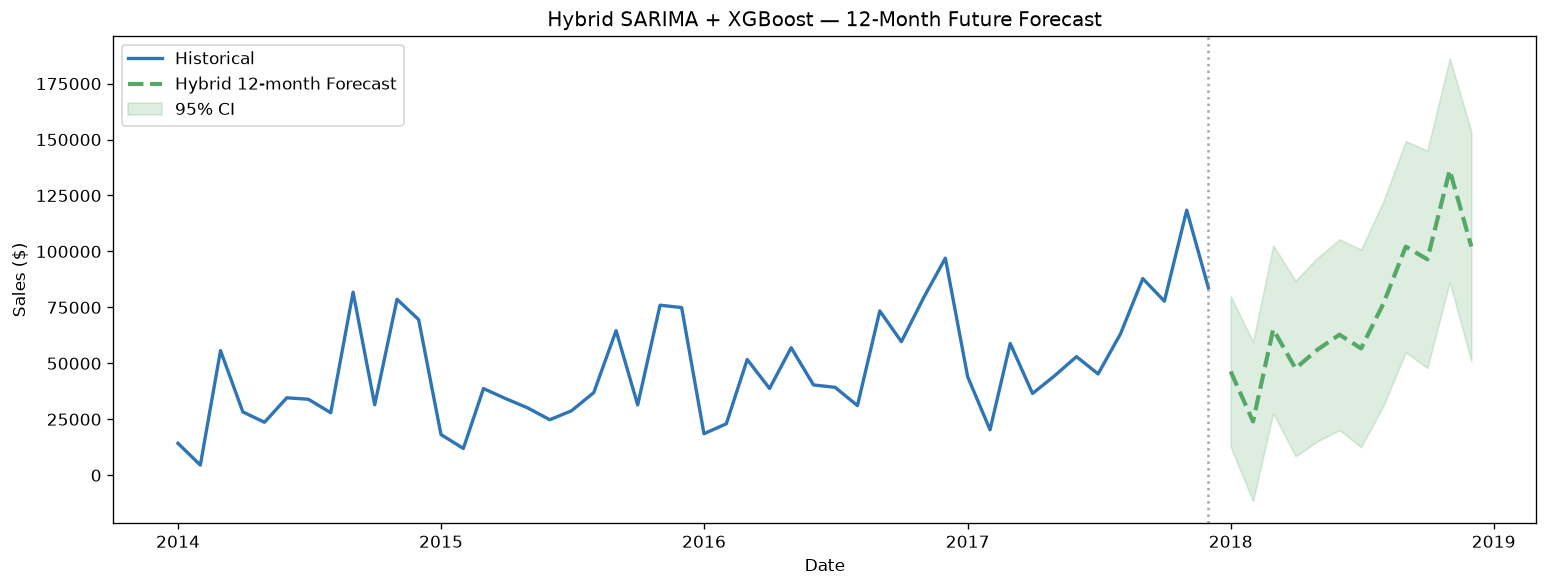

In [10]:
FUTURE_MONTHS = 12

# Refit SARIMA on all data
sarima_full = SARIMAX(
    monthly,
    order          = best_order,
    seasonal_order = best_seasonal,
    enforce_stationarity  = False,
    enforce_invertibility = False,
).fit(disp=False)

future_sarima    = sarima_full.get_forecast(steps=FUTURE_MONTHS)
future_sarima_fc = future_sarima.predicted_mean
future_ci        = future_sarima.conf_int(alpha=0.05)

# Build future residual correction features
all_residuals   = monthly - sarima_full.fittedvalues
future_dates    = future_sarima_fc.index
fut_resid_feat  = pd.DataFrame(index=future_dates)
fut_resid_feat['month']     = future_dates.month
fut_resid_feat['quarter']   = future_dates.quarter
fut_resid_feat['month_sin'] = np.sin(2 * np.pi * future_dates.month / 12)
fut_resid_feat['month_cos'] = np.cos(2 * np.pi * future_dates.month / 12)

last_r = list(all_residuals.values[-12:])
for lag in [1, 2, 3, 6, 12]:
    fut_resid_feat[f'resid_lag_{lag}'] = last_r[-lag] if lag <= len(last_r) else 0
fut_resid_feat['resid_roll3'] = np.mean(last_r[-3:]) if len(last_r) >= 3 else 0
fut_resid_feat['resid_roll6'] = np.mean(last_r[-6:]) if len(last_r) >= 6 else 0
for col in FEAT_COLS:
    if col not in fut_resid_feat.columns:
        fut_resid_feat[col] = 0
fut_resid_feat = fut_resid_feat[FEAT_COLS]

xgb_fut_correction = xgb_resid.predict(fut_resid_feat)
hybrid_future       = future_sarima_fc.values + xgb_fut_correction

# Widen CI slightly to account for XGBoost uncertainty
ci_width = (future_ci.iloc[:,1] - future_ci.iloc[:,0]).values / 2
hybrid_lower = hybrid_future - ci_width * 1.1
hybrid_upper = hybrid_future + ci_width * 1.1

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly.values, color='#2E75B6', lw=2, label='Historical')
ax.plot(future_dates, hybrid_future, color='#55A868', lw=2.5,
        linestyle='--', label='Hybrid 12-month Forecast')
ax.fill_between(future_dates, hybrid_lower, hybrid_upper,
                alpha=0.20, color='#55A868', label='95% CI')
ax.axvline(monthly.index[-1], color='gray', linestyle=':', alpha=0.7)
ax.set(title='Hybrid SARIMA + XGBoost — 12-Month Future Forecast',
       xlabel='Date', ylabel='Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '15_hybrid_future.png', bbox_inches='tight')
plt.show()

## 9. Save Models

In [11]:
joblib.dump(sarima_full,  MODEL_DIR / 'hybrid_sarima.pkl')
joblib.dump(xgb_resid,    MODEL_DIR / 'hybrid_xgb_residuals.pkl')
joblib.dump(FEAT_COLS,    MODEL_DIR / 'hybrid_xgb_feature_cols.pkl')

hybrid_metrics = {
    'model': 'Hybrid SARIMA+XGB',
    'mape':  round(hybrid_mape, 2),
    'rmse':  round(float(hybrid_rmse), 0),
    'mae':   round(float(mean_absolute_error(test.values, hybrid_pred)), 0),
}
with open(MODEL_DIR / 'hybrid_metrics.json', 'w') as f:
    json.dump(hybrid_metrics, f)

print('Saved:')
print('  models/hybrid_sarima.pkl')
print('  models/hybrid_xgb_residuals.pkl')
print(f'\nHybrid MAPE: {hybrid_mape:.2f}%')
print(f'SARIMA MAPE: {sarima_mape:.2f}%')
print(f'Improvement: {improvement:+.2f}%')
print('\nNext: open 06_deep_learning.ipynb')

Saved:
  models/hybrid_sarima.pkl
  models/hybrid_xgb_residuals.pkl

Hybrid MAPE: 30.11%
SARIMA MAPE: 28.92%
Improvement: -1.19%

Next: open 06_deep_learning.ipynb
